# End to end toy project

In [3]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv("placement.csv")

In [5]:
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [6]:
df.head(2)

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0


In [7]:
df.info

<bound method DataFrame.info of     Unnamed: 0  cgpa     iq  placement
0            0   6.8  123.0          1
1            1   5.9  106.0          0
2            2   5.3  121.0          0
3            3   7.4  132.0          1
4            4   5.8  142.0          0
..         ...   ...    ...        ...
95          95   4.3  200.0          0
96          96   4.4   42.0          0
97          97   6.7  182.0          1
98          98   6.3  103.0          1
99          99   6.2  113.0          1

[100 rows x 4 columns]>

In [8]:
df.shape

(100, 4)

In [9]:
df = df.iloc[:, 1:]

In [10]:
df.shape

(100, 3)

In [11]:
# preprocessing + eda + feature selection

In [12]:
import matplotlib.pyplot as plt

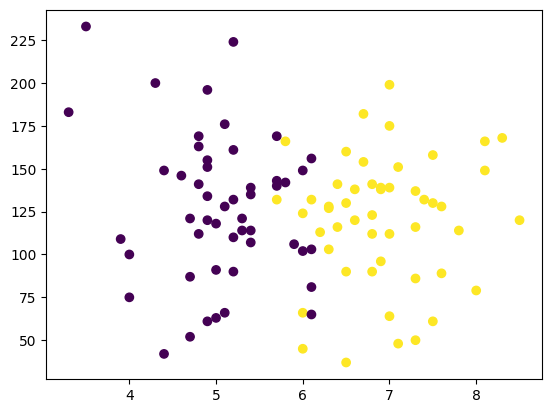

In [13]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])
# -- 0 and 1 are the colors
# plt.scatter(df['cgpa'],df['iq'],c=df['placement'],cmap='viridis')

In [14]:
x = df.drop(['placement'], axis='columns')

In [15]:
y = df['placement']

In [16]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [17]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [18]:
print(x.shape, y.shape)

(100, 2) (100,)


In [19]:
# train test split

from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [21]:
X_train.shape

(80, 2)

In [22]:
X_test.shape

(20, 2)

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()

In [25]:
X_train = scaler.fit_transform(X_train)

In [26]:
X_test = scaler.transform(X_test)

In [27]:
# model

from sklearn.linear_model import LogisticRegression

cd = LogisticRegression()

In [28]:
cd.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
y_pred = cd.predict(X_test)

In [30]:
y_test

26    1
86    0
2     0
55    1
75    0
93    1
16    0
73    0
54    1
95    0
53    1
92    0
78    0
13    1
7     0
30    1
22    0
24    0
33    0
8     0
Name: placement, dtype: int64

In [31]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)*100

85.0

In [32]:
import pickle

In [33]:
pickle.dump(cd,open("model.pkl","wb"))

    Data collection
    Data cleaning
    Data preprocessing
    Data visualization
    Feature Selection
    Model Selection
    Model Training
    Model Evaluation


# Part - 1 Data Gathering

How to Frame a machine learning problem?

How to convert business problem into machine learning problem?

    Data Gathering :-

In [ ]:
#Basic method of gathering --- 
import pandas as pd

df = pd.read_csv('data.csv')

In [36]:
df.head(2)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0


In [ ]:
#gathering the data from the url :- 
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df1 = pd.read_csv(url)

In [38]:
df1.head(2)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa


In [ ]:
#when you get the comma seperated value then you have to use the sep="," in the read_csv function. 
df = pd.read_csv("data.csv", sep=",")

In [39]:
pd.read_json('train.json')

,id,cuisine,ingredients
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes..."
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g..."
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g..."
3,22213,indian,"[water, vegetable oil, wheat, salt]"
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe..."
...,...,...,...
39769,29109,irish,"[light brown sugar, granulated sugar, butter, ..."
39770,11462,italian,"[KRAFT Zesty Italian Dressing, purple onion, b..."
39771,2238,irish,"[eggs, citrus fruit, raisins, sourdough starte..."
39772,41882,chinese,"[boneless chicken skinless thigh, minced garli..."


DATA GATHERING FROM ANY DATABASES

In [41]:
pip install mysql.connector

     ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
     ----- ---------------------------------- 1.6/11.9 MB 10.3 MB/s eta 0:00:02
     -------------- ------------------------- 4.2/11.9 MB 11.6 MB/s eta 0:00:01
     ----------------------- ---------------- 7.1/11.9 MB 13.0 MB/s eta 0:00:01
     -------------------------------- ------- 9.7/11.9 MB 12.6 MB/s eta 0:00:01
     ---------------------------------------- 11.9/11.9 MB 12.6 MB/s  0:00:01
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for mysql.connector: filename=mysql_connector-2.2.9-cp313-cp313-win_amd64.whl size=248050 sha256=435f82a475eb179

In [ ]:
conn = mysql.connector.connect(host="",user="",password = "",database="")

In [ ]:
pd.read_sql_query("select * from city",conn)

WEB=SCRAPING

In [44]:
pip install requests beautifulsoup4 lxml pandas

Note: you may need to restart the kernel to use updated packages.


# Data Understanding

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("placement.csv")

In [4]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df.sample(4) #getting the random data

# -- 0 and 1 -- classification problem -- supervised learning

,Unnamed: 0,cgpa,iq,placement
74,74,6.7,154.0,1
60,60,6.9,139.0,1
88,88,4.4,149.0,0
36,36,5.7,140.0,0


In [ ]:
df.shape #understading the shape of the data

(100, 4)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [10]:
df.isnull().sum()

Unnamed: 0    0
cgpa          0
iq            0
placement     0
dtype: int64

In [11]:
df.describe()

,Unnamed: 0,cgpa,iq,placement
count,100.000000,100.000000,100.000000,100.000000
mean,49.500000,5.991000,123.580000,0.500000
std,29.011492,1.143634,39.944198,0.502519
min,0.000000,3.300000,37.000000,0.000000
25%,24.750000,5.075000,101.500000,0.000000
50%,49.500000,6.000000,127.500000,0.500000
75%,74.250000,6.900000,149.000000,1.000000
max,99.000000,8.500000,233.000000,1.000000


In [12]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.corr()  # it will explains the correlation between columns

,Unnamed: 0,cgpa,iq,placement
Unnamed: 0,1.000000,0.047478,-0.019080,0.144807
cgpa,0.047478,1.000000,-0.098791,0.821688
iq,-0.019080,-0.098791,1.000000,-0.083031
placement,0.144807,0.821688,-0.083031,1.000000


# Exploratory Data Analysis

In [ ]:
# It is the very important concept of Machine Learning bcuz here you will learn the acutal concepts of the data...............


In [ ]:
# Data -- Numerical data(2,4,542) and Categorical data(male,female) --++
# Univariate -- Single variable analysis --
# Bivariate  -- Two variable analysis --

In [15]:
df = pd.read_csv('tested.csv')

In [16]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

# Categorical Data's

<Axes: xlabel='Survived'>

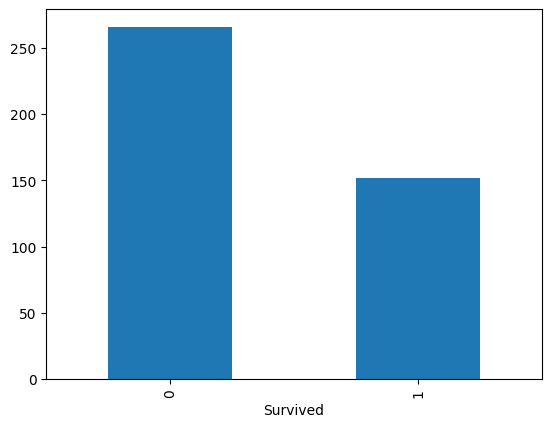

In [20]:
# Count Plot
import seaborn as sns

df['Survived'].value_counts().plot(kind='bar')

<Axes: xlabel='Pclass'>

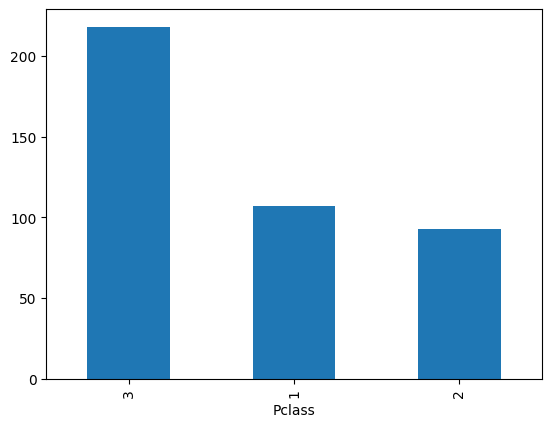

In [21]:
df['Pclass'].value_counts().plot(kind='bar')

In [23]:
df['Embarked'].value_counts()

Embarked
S    270
C    102
Q     46
Name: count, dtype: int64

<Axes: xlabel='Embarked'>

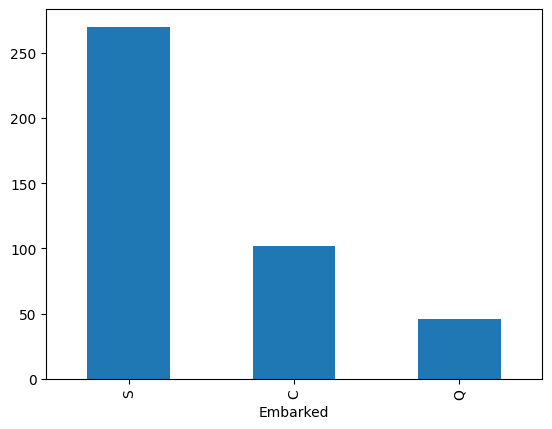

In [22]:
df['Embarked'].value_counts().plot(kind='bar')

# Pie Chart

<Axes: ylabel='count'>

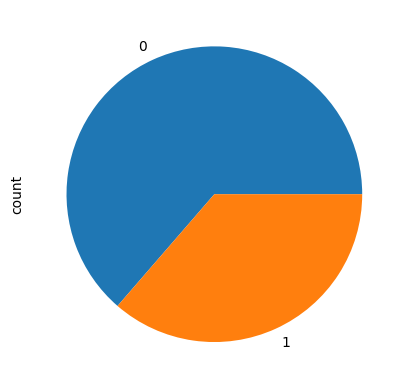

In [24]:
df['Survived'].value_counts().plot(kind = 'pie')

(array([ 8.,  3.,  0.,  4.,  1.,  4.,  2.,  3.,  3.,  4.,  2., 20.,  7.,
        25., 17., 28., 11., 25.,  8., 25., 12.,  8.,  7., 10.,  6.,  7.,
        11.,  5.,  5.,  9.,  8.,  5.,  8.,  1.,  3.,  2.,  6.,  3.,  2.,
         4.,  3.,  2.,  3.,  0.,  1.,  0.,  0.,  0.,  0.,  1.]),
 array([ 0.17  ,  1.6866,  3.2032,  4.7198,  6.2364,  7.753 ,  9.2696,
        10.7862, 12.3028, 13.8194, 15.336 , 16.8526, 18.3692, 19.8858,
        21.4024, 22.919 , 24.4356, 25.9522, 27.4688, 28.9854, 30.502 ,
        32.0186, 33.5352, 35.0518, 36.5684, 38.085 , 39.6016, 41.1182,
        42.6348, 44.1514, 45.668 , 47.1846, 48.7012, 50.2178, 51.7344,
        53.251 , 54.7676, 56.2842, 57.8008, 59.3174, 60.834 , 62.3506,
        63.8672, 65.3838, 66.9004, 68.417 , 69.9336, 71.4502, 72.9668,
        74.4834, 76.    ]),
 <BarContainer object of 50 artists>)

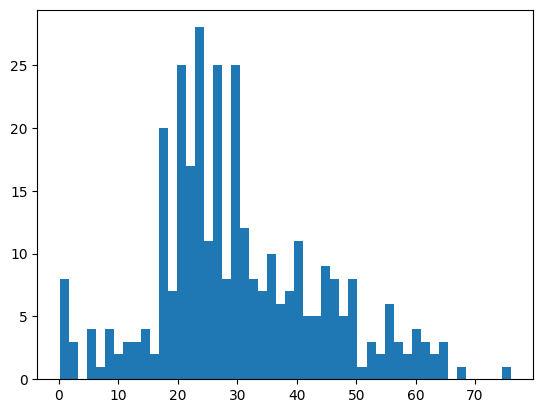

In [27]:
# Numerical data -- Univariate 

# Histogram 
import matplotlib.pyplot as plt

plt.hist(df['Age'],bins=50)